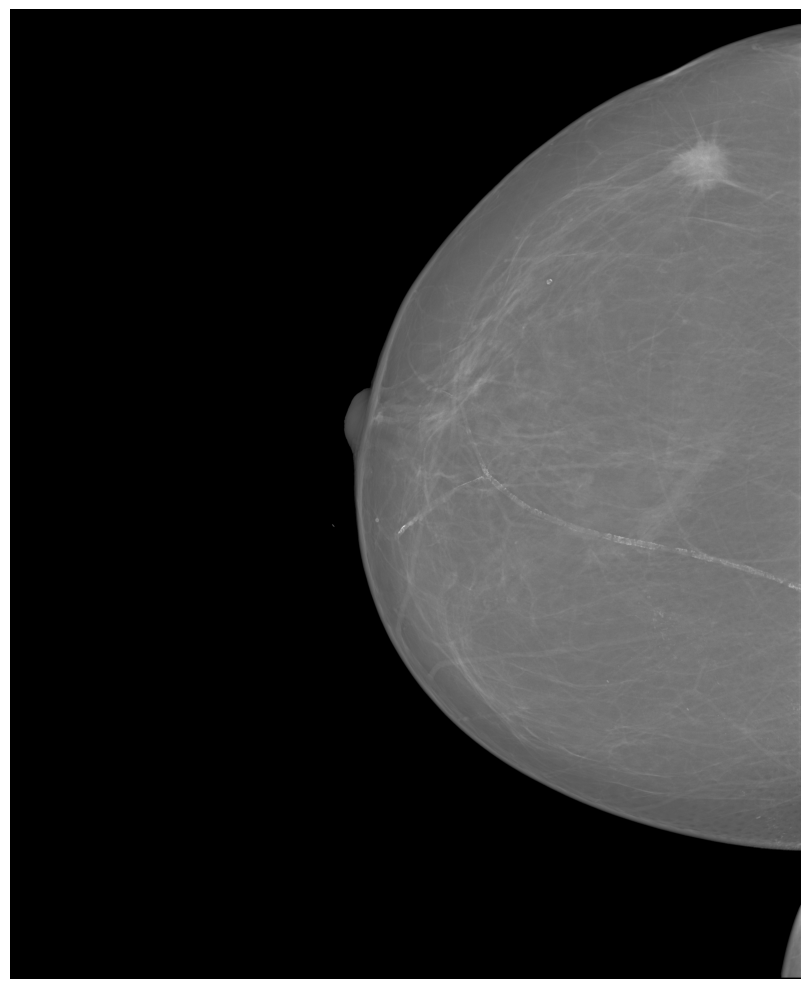

In [22]:

import numpy as np
import matplotlib.pyplot as plt
import pydicom
from roifile import ImagejRoi
from skimage.draw import polygon


def load_dicom(dicom_path: str) -> np.ndarray:
    """
    Read a DICOM image and return a display‑ready float array in the range [0, 1].
    
    Parameters
    ----------
    dicom_path : str
        Path to the input `.dcm` file.
    
    Returns
    -------
    np.ndarray
        2‑D float32 array (H × W) scaled to [0, 1] for visualization.
    """
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)
    # Apply linear rescale if present
    img *= float(ds.get("RescaleSlope", 1.0))
    img += float(ds.get("RescaleIntercept", 0.0))
    # Min‑max normalisation for display
    img -= img.min()
    img /= img.max() + 1e-8
    return img


import plistlib, re, numpy as np
from pathlib import Path
from skimage.draw import polygon


def load_plist_rois(xml_path: str,
                    image_shape: tuple[int, int]) -> tuple[np.ndarray,
                                                           tuple[int, int, int, int]]:
    """
    Convert OsiriX-exported XML/Plist ROIs to a binary mask.

    Parameters
    ----------
    xml_path : str
        Path to the *.xml* (plist) file.
    image_shape : (H, W)
        Shape of the target image (= DICOM slice).

    Returns
    -------
    mask : np.ndarray[bool]
        Union of all polygon/freehand ROIs.
    bbox : (xmin, ymin, xmax, ymax)
        Axis-aligned bounding box around that union.
    """
    # -- 1. read plist ----------------------------------------------------
    with open(xml_path, "rb") as fh:
        P = plistlib.load(fh)

    roi_dicts = P["Images"][0]["ROIs"]           # first (and only) mammogram
    floats = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"  # float regex
    coord_re = re.compile(rf"\(\s*({floats})\s*,\s*({floats})")

    H, W = image_shape
    mask = np.zeros((H, W), bool)
    xs_union, ys_union = [], []                  # collect for global bbox

    for roi in roi_dicts:
        roi_type = roi.get("Type")               # 9 = closed, 15 = freehand
        pts      = roi.get("Point_px", [])

        keep = roi_type in (9, 15) and len(pts) >= 3
        if not keep:
            continue

        xs, ys = [], []
        for s in pts:
            m = coord_re.match(s)
            if m:
                xs.append(float(m.group(1)))
                ys.append(float(m.group(2)))

        if len(xs) < 3:
            continue

        # rasterise this ROI
        rr, cc = polygon(ys, xs, shape=mask.shape)
        mask[rr, cc] = True
        xs_union.extend(xs)
        ys_union.extend(ys)

    if not xs_union:                             # nothing found -> fail loudly
        raise RuntimeError("No polygon/freehand ROI found in plist.")

    xmin, xmax = int(min(xs_union)), int(max(xs_union))
    ymin, ymax = int(min(ys_union)), int(max(ys_union))
    return mask, (xmin, ymin, xmax, ymax)


import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# show_tasks_v2  –  1×3 figure w/ a., b., c. labels and requested tweaks
# ---------------------------------------------------------------------
def show_tasks(image: np.ndarray,
                  mask:  np.ndarray,
                  class_label: str = "BI-RAD-4") -> None:
    """
    Render (a) Classification, (b) Detection, (c) Segmentation.

    Parameters
    ----------
    image : np.ndarray
        Grayscale image (H×W) scaled to [0, 1].
    mask : np.ndarray[bool]
        Boolean segmentation mask (same H×W).
    class_label : str, default "BI-RAD-4"
        Image-level label to draw in panel (a).
    """
    h, w = image.shape
    letters = ["a.", "b.", "c."]

    # --- bounding-box from circular mask --------------------------------
    ys, xs = np.where(mask)                # rows, cols of tumour pixels
    ymin, ymax = ys.min(), ys.max()
    xmin, xmax = xs.min(), xs.max()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # ====================== Panel (a) – Classification ==================
    ax = axes[0]
    ax.imshow(image, cmap="gray")
    # green frame
    ax.add_patch(plt.Rectangle((0, 0), w, h, ec="lime", lw=2, fc="none"))
    # centred BI-RADS label
    ax.text(w/2, h/2, class_label, color="lime", weight="bold",
            fontsize=16, ha="center", va="center",
            bbox=dict(fc="black", alpha=0.35, pad=2))
    # panel letter
    ax.text(5, 20, letters[0], color="white", fontsize=14, weight="bold")
    ax.axis("off")

    # ======================= Panel (b) – Detection ======================
    ax = axes[1]
    ax.imshow(image, cmap="gray")
    ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                               ec="cyan", lw=2, fc="none"))
    ax.text(xmin, ymin - 12, "tumor", color="cyan", weight="bold",
            fontsize=14, bbox=dict(fc="black", alpha=0.35, pad=2))
    ax.text(5, 20, letters[1], color="white", fontsize=14, weight="bold")
    ax.axis("off")

    # ===================== Panel (c) – Segmentation =====================
    ax = axes[2]
    # build RGB overlay via np.where
    overlay = np.dstack([image, image, image])          # greyscale → RGB
    overlay[..., 1] = np.where(mask, 1.0, overlay[..., 1])  # tint G-channel
    ax.imshow(overlay)
    ax.text(5, 20, letters[2], color="white", fontsize=14, weight="bold")
    ax.axis("off")

    plt.tight_layout()
    plt.show()



# ---------------------------------------------------------------------------
# Input paths (adapt to your own directory structure if needed)
import os
path = "/home/mario/Documents/inbreast"
dicom_path = os.path.join(path, "20587612.dcm")
xml_path   = os.path.join(path, "20587612.xml")

# Pipeline
img = load_dicom(dicom_path)
plt.figure(figsize=(12, 10))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.savefig("dicom.svg", dpi=300, format="svg")